# Exploratory Data Analysis Organized

In [1]:
print('Kernel test')

Kernel test


In [2]:
# Step 0, lets import the regular stuff we will probably need
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
summarize)
print('Done part 1212323')

# MORE MOUSE BITES
# Ehh, we should really start learning SCIKITLEARN next or whatever its called
# but I think for this project its not horrible to stick with the ISLP resources
# since we ARE straying from the notes now
from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import \
(LinearDiscriminantAnalysis as LDA ,
QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import re
print('Done part 2 with git')

Done part 1212323
Done part 2 with git


In [53]:
# Import the data:
Titanic_train = pd.read_csv('titanic_data/train.csv')

Titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Here is the summary of our EDA.

<img src="images_titanic/EDA summary.png" width="1300">

The plan is this:

 1(a)Drop 'PassengerId' column

 1(b) Create column called 'Title' to estimate the missing ages. Estimate missing ages

 1(c) Combine SibSp and ParCh columns into one (SibSp + ParCh). Then make it into bins (we dont want bins that are too small, to avoid overfitting). Drop 'SibSP', 'ParCh' columns as well as any created temporarily to calculate this Family_Bins style column

 1(d) Make 'Has_Cabin_Record' column. Drop 'Cabin' column 

 1(e) Use ticket to calculate log+1(Fare). Create 'log_plus1_Fare' column. Drop 'Fare' and 'Ticket' columns.

 1(f) Delete the rows where 'Embarked' is null. Setup so that for future training, we assume Embarked = Mode (S?)

In [54]:
#1(a)

# We drop the useless looking column
Titanic_train = Titanic_train.drop(columns='PassengerId')

Titanic_train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [55]:
# 1(b)

print('The median age  was ' + str(Titanic_train['Age'].median()))

# Then we use regex to find the different groups, and make a new column. The column we care about is 'Name', we categorize according to cat we found and what google says they mean
conditions_name = [
    Titanic_train['Name'].str.contains(r'Master') 
    , Titanic_train['Name'].str.contains(r'Mrs.') | Titanic_train['Name'].str.contains(r'Mme.')# Married woman Mme
    , Titanic_train['Name'].str.contains(r'Mr.') # Mr.
    , Titanic_train['Name'].str.contains(r'Miss.') | Titanic_train['Name'].str.contains(r'Mlle.') # Girl or unmarried woman, Unmarried
]

choices_name = ['Master'
                , 'Mrs/Mme'
                , 'Mr'
                , 'Miss/Mlle']

Titanic_train['Title'] = np.select(conditions_name, choices_name, default = 'Other')

# We review the value counts, Other is a BIT suspect in terms of being too small a category, but since we are using this for age estimation as opposed to category, I think this is ok
Titanic_train['Title'].value_counts()

Titanic_train['Age'] = Titanic_train['Age'].fillna(
    Titanic_train.groupby('Title')['Age'].transform('median')
)

print('The median age has changed to be ' + str(Titanic_train['Age'].median()))

The median age  was 28.0
The median age has changed to be 30.0


In [56]:
# 1(c)
Titanic_train['Family'] = Titanic_train['SibSp']+Titanic_train['Parch']

# Create bins for SibSp and ParCh
bins_01_2 = [-0.5, 0.5, 1.5, 1000]
labels_01_2 = ['Zero', 'One', 'Two or more']

# Create bins for "Family"
bins_012_3 = [-0.5, 0.5, 1.5, 2.5, 1000]
labels_012_3 = ['Zero', 'One', 'Two', 'Three or more']

Titanic_train['Sibsp_bins'] = pd.cut(Titanic_train['SibSp'], bins_01_2, labels = labels_01_2)
Titanic_train['Parch_bins'] = pd.cut(Titanic_train['Parch'], bins_01_2, labels = labels_01_2)
Titanic_train['Family_bins'] = pd.cut(Titanic_train['Family'], bins_012_3, labels = labels_012_3)
Titanic_train.head(10)

# Drop actual values. Bins to be decided later
Titanic_train = Titanic_train.drop(columns='SibSp')
Titanic_train = Titanic_train.drop(columns='Parch')
Titanic_train = Titanic_train.drop(columns='Family')

In [57]:
# 1(d)
Titanic_train['Has_Cabin_Record'] = Titanic_train['Cabin'].notna().astype(int)

Titanic_train = Titanic_train.drop(columns='Cabin')

In [58]:
# 1(e)

ticket_counts = Titanic_train['Ticket'].value_counts()
group_size_by_ticket = Titanic_train['Ticket'].map(ticket_counts)

Titanic_train['Individual_Fare_LogPlus1'] = np.log1p(Titanic_train['Fare'] / group_size_by_ticket)

Titanic_train = Titanic_train.drop(columns='Fare')
Titanic_train = Titanic_train.drop(columns='Ticket')

In [59]:
# 1(f)
Titanic_train = Titanic_train.dropna(subset=['Embarked'])

# 1(g) (For test data:) Fill missing 'Embarked' values in the test set with 'S'
#Titanic_test['Embarked'] = Titanic_test['Embarked'].fillna('S')

In [60]:
# 1(g) 
Titanic_train = Titanic_train.drop(columns='Name')
Titanic_train = Titanic_train.drop(columns='Title')

In [61]:
# 1(h) 
# Change the data type of some of the columns to the 'category' data type to make them easier to manipulate.
Titanic_train['Sex'] = Titanic_train['Sex'].astype('category')
Titanic_train['Embarked'] = Titanic_train['Embarked'].astype('category')

In [62]:
# Final checkup
Titanic_train

,Survived,Pclass,Sex,Age,Embarked,Sibsp_bins,Parch_bins,Family_bins,Has_Cabin_Record,Individual_Fare_LogPlus1
0,0,3,male,22.0,S,One,Zero,One,0,2.110213
1,1,1,female,38.0,C,One,Zero,One,1,4.280593
2,1,3,female,26.0,S,Zero,Zero,Zero,0,2.188856
3,1,1,female,35.0,S,One,Zero,One,1,3.316003
4,0,3,male,35.0,S,Zero,Zero,Zero,0,2.202765
...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,S,Zero,Zero,Zero,0,2.639057
887,1,1,female,19.0,S,Zero,Zero,Zero,1,3.433987
888,0,3,female,21.0,S,One,Two or more,Three or more,0,2.543569
889,1,1,male,26.0,C,Zero,Zero,Zero,1,3.433987


In [63]:
# So the question becomes 'how do we choose which model to use to train the data'. Well lets list out the possible models that chapter 4 has given us:
# Logistic Regression
# Linear Discriminant Analysis
# Quadratic Discriminant Analysis
# Naive Bayes
# KNN

# Most likely its gonna be QDA but it could be LDA or even Logistic Regression.
# I doubt it will be Naive Bayes due to the number of predictor parameters and the comparative lack of data
# As for Naive Bayes I dont even remember what that one is but it sounds not very flexible. We can look into it.

# So, plan is to fit the model with LR, LDA and QDA. Then investigate Naive Bayes Definition.,

# Then compare model fit using cross validation in 5 groups (the standard)

# Pick the model which has the best Cross-Validation results.

# Fit the data. Kachapaow! Donezo.

# Logistic Regression:

#Titanic_train.describe()

# Titanic train with family column
Titanic_train_f = Titanic_train.copy()
Titanic_train_f  = Titanic_train_f.drop(columns='Sibsp_bins')
Titanic_train_f  = Titanic_train_f.drop(columns='Parch_bins')

# Titanic train with siblings-spouse and parent-child columns
Titanic_train_sp = Titanic_train.copy()
Titanic_train_sp  = Titanic_train_sp.drop(columns='Family_bins')

# Titanic train data for Family version, without the response
Titanic_train_LR_f = Titanic_train_f.copy()
Titanic_train_LR_f  = Titanic_train_f.drop(columns='Survived')

# Titanic train data for SibSpouse-ParChild version, without the response
Titanic_train_LR_sp = Titanic_train_sp.copy()
Titanic_train_LR_sp  = Titanic_train_sp.drop(columns='Survived')


design_LR_f = MS(Titanic_train_LR_f)

X_LR_f = design_LR_f.fit_transform(Titanic_train_f)

Y_LR_f = Titanic_train_f.Survived == 1

glm_LR_f = sm.GLM(Y_LR_f, X_LR_f, family=sm.families.Binomial())

results_LR_f = glm_LR_f.fit()

summarize(results_LR_f)

#Titanic_train_f

# So we need to convert the following columns:
# Family_bins
# Title
# Embarked
# Sex

,coef,std err,z,P>|z|
intercept,3.2176,0.960,3.351,0.001
Pclass,-0.8031,0.196,-4.103,0.000
Sex[male],-2.6067,0.198,-13.173,0.000
Age,-0.0375,0.008,-4.977,0.000
Embarked[Q],-0.1346,0.380,-0.354,0.723
Embarked[S],-0.4532,0.235,-1.925,0.054
Family_bins,0.1179,0.080,1.470,0.142
Has_Cabin_Record,0.6181,0.293,2.109,0.035
Individual_Fare_LogPlus1,0.2798,0.190,1.469,0.142


In [51]:
Titanic_train_f

,Survived,Pclass,Sex,Age,Embarked,Title,Family_bins,Has_Cabin_Record,Individual_Fare_LogPlus1
0,0,3,male,22.0,S,Mr,One,0,2.110213
1,1,1,female,38.0,C,Mrs/Mme,One,1,4.280593
2,1,3,female,26.0,S,Miss/Mlle,Zero,0,2.188856
3,1,1,female,35.0,S,Mrs/Mme,One,1,3.316003
4,0,3,male,35.0,S,Mr,Zero,0,2.202765
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,S,Other,Zero,0,2.639057
887,1,1,female,19.0,S,Miss/Mlle,Zero,1,3.433987
888,0,3,female,21.0,S,Miss/Mlle,Three or more,0,2.543569
889,1,1,male,26.0,C,Mr,Zero,1,3.433987


$\mathbb{P} [Y = k | X = x ] = \frac{e^{\beta_{k_0} + \beta_{k_1} x_1 + ... + \beta_{k_p} x_p}}{1 + \sum{^{k-1}_{l=1} e^{\beta_{l_0} + \beta_{l_1} x_1 + ... + \beta_{l_p} x_p}}}$



In [44]:
# 1. Print the actual data types of the final transformed DataFrame
print("--- Final Matrix Column Dtypes ---")
print(X_LR_f.dtypes)
print("\n" + "="*40 + "\n")

# 2. Automatically isolate and flag the problematic columns
problem_cols = X_LR_f.select_dtypes(include=['object']).columns.tolist()

if len(problem_cols) > 0:
    print(f"🚨 Found {len(problem_cols)} problematic object column(s):")
    for col in problem_cols:
        print(f" - {col}")
    
    print("\n💡 Sample values from the broken columns:")
    print(X_LR_f[problem_cols].head())
else:
    print("✅ All columns in X_LR_f are numerical! The issue might be in Y_LR_f.")

--- Final Matrix Column Dtypes ---
intercept                   float64
Pclass                        int64
Sex                          object
Age                         float64
Embarked                     object
Title                        object
Family_bins                 float64
Has_Cabin_Record              int64
Individual_Fare_LogPlus1    float64
dtype: object


🚨 Found 3 problematic object column(s):
 - Sex
 - Embarked
 - Title

💡 Sample values from the broken columns:
      Sex Embarked      Title
0    male        S         Mr
1  female        C    Mrs/Mme
2  female        S  Miss/Mlle
3  female        S    Mrs/Mme
4    male        S         Mr


array([[<Axes: xlabel='Survived', ylabel='Survived'>,
        <Axes: xlabel='Pclass', ylabel='Survived'>,
        <Axes: xlabel='Age', ylabel='Survived'>,
        <Axes: xlabel='Has_Cabin_Record', ylabel='Survived'>,
        <Axes: xlabel='Individual_Fare_LogPlus1', ylabel='Survived'>],
       [<Axes: xlabel='Survived', ylabel='Pclass'>,
        <Axes: xlabel='Pclass', ylabel='Pclass'>,
        <Axes: xlabel='Age', ylabel='Pclass'>,
        <Axes: xlabel='Has_Cabin_Record', ylabel='Pclass'>,
        <Axes: xlabel='Individual_Fare_LogPlus1', ylabel='Pclass'>],
       [<Axes: xlabel='Survived', ylabel='Age'>,
        <Axes: xlabel='Pclass', ylabel='Age'>,
        <Axes: xlabel='Age', ylabel='Age'>,
        <Axes: xlabel='Has_Cabin_Record', ylabel='Age'>,
        <Axes: xlabel='Individual_Fare_LogPlus1', ylabel='Age'>],
       [<Axes: xlabel='Survived', ylabel='Has_Cabin_Record'>,
        <Axes: xlabel='Pclass', ylabel='Has_Cabin_Record'>,
        <Axes: xlabel='Age', ylabel='Has_Cabin_Re

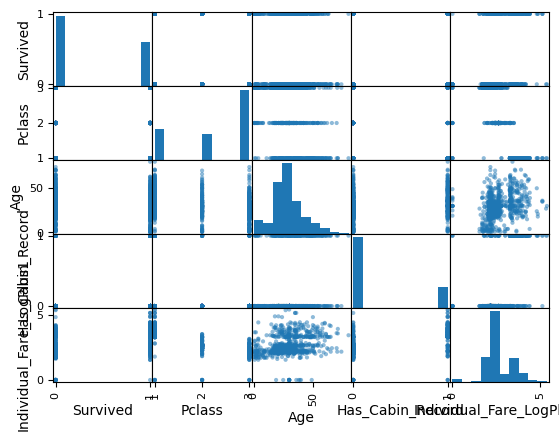

In [16]:
pd.plotting.scatter_matrix(Titanic_train)